In [25]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



In [27]:
df = pd.read_excel('bioactivity_dataset_cleaned_outliers.xlsx')
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
df = df.dropna(subset=['mol'])

# Compute/scale descriptors (if not already)
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return np.zeros(4)
    return np.array([Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol),
                Descriptors.NumHDonors(mol),
                Descriptors.NumHAcceptors(mol),
                Descriptors.NumRotatableBonds(mol),
                Descriptors.NumAromaticRings(mol),
                Descriptors.FractionCSP3(mol)])

df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']] = df['canonical_smiles'].apply(compute_descriptors).tolist()

# scaler = StandardScaler()
# desc_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']
# df[desc_cols] = scaler.fit_transform(df[desc_cols])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5667 entries, 0 to 5666
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5667 non-null   object 
 1   MW                 5667 non-null   float64
 2   LogP               5667 non-null   float64
 3   NumHDonors         5667 non-null   float64
 4   NumHAcceptors      5667 non-null   float64
 5   pIC50              5667 non-null   float64
 6   bioactivity_class  5667 non-null   object 
 7   bioactivity        5667 non-null   int64  
 8   mol                5667 non-null   object 
 9   TPSA               5667 non-null   float64
 10  NumRotatableBonds  5667 non-null   float64
 11  NumAromaticRings   5667 non-null   float64
 12  FractionCSP3       5667 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 575.7+ KB


In [ ]:
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity,mol,TPSA,NumRotatableBonds,NumAromaticRings,FractionCSP3
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,6.0,8.6,active,1,<rdkit.Chem.rdchem.Mol object at 0x00000181840...,129.65,11.0,3.0,0.280000
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,6.0,9.0,active,1,<rdkit.Chem.rdchem.Mol object at 0x00000181840...,133.31,10.0,4.0,0.222222
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,4.0,9.0,active,1,<rdkit.Chem.rdchem.Mol object at 0x00000181840...,107.53,7.0,3.0,0.041667


In [ ]:
df.drop(columns=['pIC50', 'bioactivity_class'], inplace=True)

In [ ]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5667 entries, 0 to 5666
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5667 non-null   object 
 1   MW                 5667 non-null   float64
 2   LogP               5667 non-null   float64
 3   NumHDonors         5667 non-null   float64
 4   NumHAcceptors      5667 non-null   float64
 5   bioactivity        5667 non-null   int64  
 6   mol                5667 non-null   object 
 7   TPSA               5667 non-null   float64
 8   NumRotatableBonds  5667 non-null   float64
 9   NumAromaticRings   5667 non-null   float64
 10  FractionCSP3       5667 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 487.1+ KB


In [ ]:
df['bioactivity'].value_counts()

bioactivity
1    4641
0    1026
Name: count, dtype: int64

In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# CONFIG (Fixed)
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 512
BATCH_SIZE = 32
ECFP_BITS = 1024
ECFP_RADIUS = 2
AUGMENT_TRAIN = True


train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

scaler=StandardScaler().fit(train_df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']])

# -------------------------------
# SMILES Augmentation
# -------------------------------
def random_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return smiles
    return Chem.MolToSmiles(mol, doRandom=True, canonical=False)

# -------------------------------
# ECFP Generator
# -------------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_BITS)
def get_ecfp(smiles, radius=ECFP_RADIUS, n_bits=ECFP_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------
# Dataset
# -------------------------------

tokenizer = AutoTokenizer.from_pretrained('DeepChem/ChemBERTa-77M-MTR')

class BioActivityDataset(Dataset):
    def __init__(self, df, tokenizer, scaler=None, ecfp_cache=None, augment=False):
        self.smiles = df['canonical_smiles'].values.tolist()
        self.desc   = df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']].values.astype(np.float32)
        self.labels = df['bioactivity'].values.astype(np.float32)
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
        self.augment = augment
        self.max_len = MAX_LEN

        
        if scaler is None:
            self.scaler = StandardScaler().fit(self.desc)
        else:
            self.scaler = scaler
        self.desc = self.scaler.transform(self.desc)
        
        print("Computing ECFP...")
        self.ecfp = np.stack([get_ecfp(s) for s in self.smiles])
        

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx): 
        item = {k: v[idx] for k, v in self.encodings.items()}

        item['ecfp']=torch.tensor(self.ecfp[idx])
        item['descriptors']=torch.tensor(self.desc[idx])
        item['labels']=torch.tensor(self.labels[idx])

        return item

# -------------------------------
# Collate Function
# -------------------------------
def collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'descriptors': torch.stack([b['descriptors'] for b in batch]),
        'ecfp': torch.stack([b['ecfp'] for b in batch]),
        'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.float)
    }



In [ ]:
# from imblearn.combine import SMOTETomek
# from imblearn.over_sampling import SMOTENC


# train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
# val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)
# #tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# class BioactivityDataset(Dataset):
#     def __init__(self, df, tokenizer, desc_scaler):
#         self.smiles = df['canonical_smiles'].tolist()
#         self.labels = df['bioactivity'].tolist()
#         self.descs = df[desc_cols].values
#         #self.desc_scaler = desc_scaler
#         self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
    
#     def __len__(self): return len(self.labels)
#     def __getitem__(self, idx):
#         item = {k: v[idx] for k, v in self.encodings.items()}
#         item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
#         item['descriptors'] = torch.tensor(self.descs[idx], dtype=torch.float)
#         return item

In [ ]:
train_dataset = BioActivityDataset(train_df, tokenizer, scaler=scaler)
val_dataset = BioActivityDataset(val_df, tokenizer, scaler=scaler)
test_dataset = BioActivityDataset(test_df, tokenizer, scaler=scaler)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Computing ECFP...
Computing ECFP...
Computing ECFP...


In [ ]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    3712
 0     821
 Name: count, dtype: int64,
 bioactivity
 1    454
 0    113
 Name: count, dtype: int64,
 bioactivity
 1    475
 0     92
 Name: count, dtype: int64)

In [ ]:
train_dataset[3]

{'input_ids': tensor([12, 19, 22, 16, 17, 39, 16, 22, 16, 39, 15, 20, 15, 15, 15, 21, 15, 17,
         22, 19, 18, 25, 17, 16, 16, 15, 26, 15, 15, 15, 15, 15, 26, 18, 15, 25,
         15, 21, 15, 20, 18, 23, 19, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
   

<!-- #### ECFP + BERT embedding based model -->

In [ ]:
# -------------------------------
# Model
# -------------------------------
class FineTunedBERTaECFP(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, unfreeze_layers=12, num_heads=8, dropout=0.5, hidden_dim=512):
        super().__init__()
        self.bert = AutoModel.from_pretrained("DeepChem/ChemBERTa-77M-MTR", trust_remote_code=True)

        # Unfreeze last N layers
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Project ECFP and descriptors to 768
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 384),
            nn.LayerNorm(384),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.desc_proj = nn.Sequential(
            nn.Linear(8, 384),
            nn.LayerNorm(384),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Attention
        self.attn = nn.MultiheadAttention(384, num_heads=num_heads, batch_first=True, dropout=dropout)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(384 * 3, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )


    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # SMILES
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_ = out.last_hidden_state[:,0]
        mean_pool = out.last_hidden_state.mean(dim=1)  # [B,768]
        smiles = (cls_+mean_pool)/2

        # ECFP + Desc
        ecfp_emb = self.ecfp_proj(ecfp)             # [B,768]
        desc_emb = self.desc_proj(descriptors)      # [B,768]

        # Attention
        q = torch.stack([ecfp_emb, desc_emb], dim=1)  # [B,2,768]
        kv = smiles.unsqueeze(1)                       # [B,1,768]
        attn_out, _ = self.attn(q, kv, kv)             # [B,2,768]
        ecfp_attn, desc_attn = attn_out[:,0], attn_out[:,1]

        # Fuse
        fused = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)  # [B,2304]
        return self.classifier(fused).squeeze(-1)

model = FineTunedBERTaECFP(unfreeze_layers=2, num_heads=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


FineTunedBERTaECFP(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(600, 384, padding_idx=1)
      (position_embeddings): Embedding(515, 384, padding_idx=1)
      (token_type_embeddings): Embedding(1, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.144, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.109, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm):

In [ ]:
# 

<!-- #### test -->

#### Test

In [ ]:
# -------------------------------
# Training Function (for Optuna)
# -------------------------------
def train_and_evaluate(trial):
    # --- Suggest Hyperparameters ---
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    lr = trial.suggest_loguniform('lr', 1e-5, 5e-5)
    dropout = trial.suggest_uniform('dropout', 0.3, 0.6)
    num_heads = trial.suggest_categorical('num_heads', [4, 8, 12])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    unfreeze_layers = trial.suggest_int('unfreeze_layers', 6, 12) 
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-3, 1e-1)

    # --- Data Loaders ---
    tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

    train_ds = BioActivityDataset(train_df, tokenizer, augment=AUGMENT_TRAIN, ecfp_cache='train_ecfp.npy')
    val_ds   = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='val_ecfp.npy')
    test_ds  = BioActivityDataset(test_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='test_ecfp.npy')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)

    # --- Model ---
    model = ChemBERTaECFP(unfreeze_layers=unfreeze_layers, num_heads=num_heads, dropout=dropout, hidden_dim=hidden_dim).to(DEVICE)

    # --- Loss ---
    pos_weight = torch.tensor([len(train_ds) - sum(train_ds.labels)] / sum(train_ds.labels)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Optimizer + Scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                               (0.5 * (1 + np.cos(np.pi * step / total_steps)))
    )

    # --- Training Loop ---
    best_auc = 0.0
    patience_counter = 0
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE)
            )
            loss = criterion(logits, batch['labels'].to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()

        # Validation
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE),
                    descriptors=batch['descriptors'].to(DEVICE),
                    ecfp=batch['ecfp'].to(DEVICE)
                )
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs.extend(probs)
                val_labels.extend(batch['labels'].numpy())

        auc = roc_auc_score(val_labels, val_probs)

        if auc > best_auc + 1e-4:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_auc  # Optuna maximizes this

# -------------------------------
# Optuna Study
# -------------------------------
if __name__ == "__main__":
    # REPLACE WITH YOUR DATAFRAMES: train_df, val_df, test_df
    # Assumes they are loaded (e.g., via pd.read_csv)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
    study.optimize(train_and_evaluate, n_trials=50)  # Run 50 trials

    print("Best hyperparameters:", study.best_params)
    print("Best val AUROC:", study.best_value)

    # --- Retrain with best params and evaluate on test ---
    # (Implement similar to train_and_evaluate, but use study.best_params and run on test)

<!-- #### BERT based -->

#### BERT based

In [27]:
class FineTunedMultimodalModel(nn.Module):
    def __init__(self, num_desc=8, emb_dim=768, hidden=512, dropout=0.5, num_layers_to_unfreeze=10, attn_heads=8):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # ---------- UNFROEZE ----------
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-num_layers_to_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------- ATTENTION FUSION ----------
        self.attn = nn.MultiheadAttention(
            embed_dim=emb_dim, num_heads=attn_heads, dropout=dropout, batch_first=True
        )

        # ---------- CLASSIFIER ----------
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)          # logits
        )

    def forward(self, input_ids, attention_mask, descriptors):
        # BERT
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_ = out.last_hidden_state[:, 0]
        mean_pool = out.last_hidden_state.mean(1)
        smiles = (cls_ + mean_pool) / 2

        # Descriptors
        desc = self.desc_proj(descriptors)                  # [B,768]

        # Attention (descriptor attends to SMILES)
        q = desc.unsqueeze(1)                               # [B,1,768]
        kv = smiles.unsqueeze(1)
        attn_out, _ = self.attn(q, kv, kv)                  # [B,1,768]
        attn_out = attn_out.squeeze(1)

        # Fuse
        fused = torch.cat([smiles, attn_out], dim=1)        # [B,1536]
        return self.classifier(fused).squeeze(-1)

model = FineTunedMultimodalModel(num_layers_to_unfreeze=12, attn_heads=8)  # Start with 4 for small data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedMultimodalModel(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

<!-- #### Another model -->

In [ ]:
# from peft import LoraConfig, get_peft_model, TaskType

# lora_config = LoraConfig( task_type=TaskType.SEQ_CLS, r=4, lora_alpha=8, target_modules=["query", "value"], lora_dropout=0.1)

In [ ]:
# model = get_peft_model(model, lora_config)
 
# # Print trainable params (should be <1% of total)
# model.print_trainable_parameters()  

trainable params: 1,026,561 || all params: 48,747,138 || trainable%: 2.1059


<!-- #### Train and evaluation -->

#### Run

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['bioactivity']), y=train_df['bioactivity'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

pos_weight = torch.tensor([3712 / 821]).to(device)  # From your imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)  # Added weight decay
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  # New: Better convergence
num_train_steps = len(train_loader) * 30
warmup_steps    = int(0.1 * num_train_steps)

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                           (0.5 * (1 + np.cos(np.pi * step / num_train_steps)))
)

# criterion = BCEWithLogitsLoss(pos_weight=class_weights[1])
epochs = 50  # Longer for fine-tuning
best_auc = 0
patience, counter = 7, 0

In [ ]:
from sklearn.metrics import precision_recall_curve

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].float().to(device)
        ecfp = batch['ecfp'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, ecfp=ecfp, descriptors=descriptors)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()  # Step LR scheduler per batch
        train_loss += loss.item()
    
    
    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            ecfp = batch['ecfp'].to(device)
            logits = model(input_ids, attention_mask, ecfp, descriptors)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(labels.cpu().numpy())
            loss = criterion(logits, labels.float())  # Compute loss for this batch
            val_loss += loss.item()  #
    
    
    auc = roc_auc_score(val_labels, val_preds)
    prec, rec, thr = precision_recall_curve(val_labels, val_preds)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1s)]
    preds = (np.array(val_preds) > best_thr).astype(int)
    acc = accuracy_score(val_labels, preds)
    f1  = f1_score(val_labels, preds)

    print(f'Epoch {epoch+1:02d} | '
          f'TrainLoss {train_loss/len(train_loader):.4f} | '
          f'ValAUROC {auc:.4f} | Acc {acc:.4f} | F1 {f1:.4f} | Thr {best_thr:.3f}')
    
    if auc > best_auc:
        best_auc = auc
        torch.save(model, 'best_finetuned_model_chem.pth')
        counter = 0
    else:
        counter += 1
        if counter >= 7:
            print("Early stopping!")
            break

Epoch 01 | TrainLoss 2.5728 | ValAUROC 0.6728 | Acc 0.8131 | F1 0.8948 | Thr 0.544
Epoch 02 | TrainLoss 1.4571 | ValAUROC 0.7565 | Acc 0.8307 | F1 0.8985 | Thr 0.727
Epoch 03 | TrainLoss 0.7411 | ValAUROC 0.8053 | Acc 0.8501 | F1 0.9139 | Thr 0.704
Epoch 04 | TrainLoss 0.6005 | ValAUROC 0.8304 | Acc 0.8571 | F1 0.9168 | Thr 0.709
Epoch 05 | TrainLoss 0.5321 | ValAUROC 0.8470 | Acc 0.8713 | F1 0.9232 | Thr 0.789
Epoch 06 | TrainLoss 0.4894 | ValAUROC 0.8539 | Acc 0.8695 | F1 0.9231 | Thr 0.760
Epoch 07 | TrainLoss 0.4540 | ValAUROC 0.8711 | Acc 0.8748 | F1 0.9258 | Thr 0.679
Epoch 08 | TrainLoss 0.4265 | ValAUROC 0.8807 | Acc 0.8801 | F1 0.9290 | Thr 0.614
Epoch 09 | TrainLoss 0.3941 | ValAUROC 0.8821 | Acc 0.8836 | F1 0.9307 | Thr 0.653
Epoch 10 | TrainLoss 0.3818 | ValAUROC 0.8868 | Acc 0.8907 | F1 0.9333 | Thr 0.757
Epoch 11 | TrainLoss 0.3712 | ValAUROC 0.8940 | Acc 0.8924 | F1 0.9345 | Thr 0.772
Epoch 12 | TrainLoss 0.3375 | ValAUROC 0.8938 | Acc 0.8977 | F1 0.9383 | Thr 0.716
Epoc

In [ ]:
loaded_model = torch.load('best_finetuned_model_chem.pth', map_location=device, weights_only=False)
loaded_model.eval()


FineTunedBERTaECFP(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(600, 384, padding_idx=1)
      (position_embeddings): Embedding(515, 384, padding_idx=1)
      (token_type_embeddings): Embedding(1, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.144, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.109, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm):

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Run inference on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.794).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

In [20]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		ecfp = batch['ecfp'].to(device)
		labels = batch['labels'].to(device)
		logits = loaded_model(input_ids, attention_mask, ecfp, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.62).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9246567505720823
Accuracy: 0.8060869565217391
accuracy another:  0.91005291005291


In [21]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

         0.0       0.76      0.65      0.70        92
         1.0       0.93      0.96      0.95       475

    accuracy                           0.91       567
   macro avg       0.85      0.81      0.82       567
weighted avg       0.91      0.91      0.91       567



In [22]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, average_precision_score
import numpy as np

y_true = np.array(test_labels)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
auprc = average_precision_score(y_true, y_prob)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)
sensitivity = recall  # same as recall

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"AUPRC: {auprc:.4f}")

Accuracy: 0.9101
Balanced Acc.: 0.8061
Precision: 0.9344
Recall: 0.9600
F1 Score: 0.9470
ROC-AUC: 0.9247
MCC: 0.6518
Specificity: 0.6522
Sensitivity: 0.9600
AUPRC: 0.9806


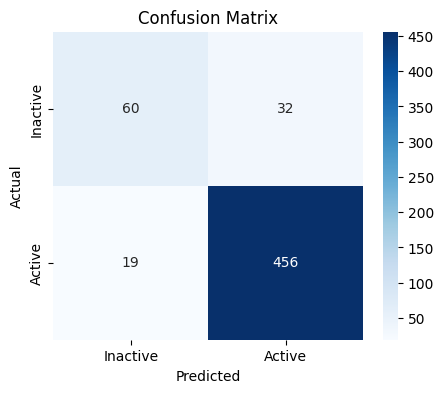

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# 